In [1]:
# Save Calibration Data to CSV
import csv
import numpy as np
from nuscenes.nuscenes import NuScenes
from pyquaternion import Quaternion

def save_calib_to_csv(nusc, sample_tokens, cam_channel="CAM_FRONT", out_csv="calibration_info.csv"):
    with open(out_csv, mode='w', newline='') as f:
        writer = csv.writer(f)
        # Write header
        writer.writerow([
            "sample_token", "cam_channel",
            "K_flat", "R_flat", "T_flat",
            "lidar2img_flat", "img_height", "img_width"
        ])
        for token in sample_tokens:
            sample = nusc.get("sample", token)
            sd_cam = nusc.get("sample_data", sample["data"][cam_channel])
            cs_cam = nusc.get("calibrated_sensor", sd_cam["calibrated_sensor_token"])
            ep_cam = nusc.get("ego_pose", sd_cam["ego_pose_token"])
            K = np.array(cs_cam["camera_intrinsic"])
            R = Quaternion(cs_cam["rotation"]).rotation_matrix
            T = np.array(cs_cam["translation"])
            img_shape = (sd_cam["height"], sd_cam["width"])

            # For lidar2img, you can adapt the logic from your original code:
            # If you also want lidar2img, you need to reconstruct the full lidar2img for each sample.
            # For now, let's assume you just want camera matrices.
            lidar2img = np.zeros((3, 4))  # Placeholder if you want to add it later

            writer.writerow([
                token, cam_channel,
                K.flatten().tolist(),
                R.flatten().tolist(),
                T.flatten().tolist(),
                lidar2img.flatten().tolist(),
                img_shape[0], img_shape[1]
            ])
    print(f"[INFO] Calibration info saved to {out_csv}")

# Example usage
nusc = NuScenes(
    version='v1.0-trainval',
    dataroot="/home/draiman/Desktop/datasets/nuscenes",
    verbose=False
)
# Define your list of tokens (could be all or just a subset)
sample_tokens = [s['token'] for s in nusc.sample[:50]]  # Example: first 50 samples
save_calib_to_csv(nusc, sample_tokens, "CAM_FRONT", "calibration_info.csv")


[INFO] Calibration info saved to calibration_info.csv


In [15]:
# Retrieve Calibration Data from CSV
import csv
import numpy as np

def load_calib_from_csv(csv_file, query_token, cam_channel="CAM_FRONT"):
    with open(csv_file, mode='r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            if row["sample_token"] == query_token and row["cam_channel"] == cam_channel:
                K = np.array(eval(row["K_flat"])).reshape(3, 3)
                R = np.array(eval(row["R_flat"])).reshape(3, 3)
                T = np.array(eval(row["T_flat"])).reshape(3,)
                lidar2img = np.array(eval(row["lidar2img_flat"])).reshape(3, 4)
                img_shape = (int(row["img_height"]), int(row["img_width"]))
                return {
                    "K": K, "R": R, "T": T, "lidar2img": lidar2img, "img_shape": img_shape
                }
    raise KeyError(f"Sample {query_token} with channel {cam_channel} not found in CSV.")

# Example usage
query_token = "e93e98b63d3b40209056d129dc53ceee"
calib_info = load_calib_from_csv("calibration_info.csv", query_token, "CAM_FRONT")
print(calib_info["K"], calib_info["R"], calib_info["T"], calib_info["img_shape"])
lidar2img_nusc = calib_info["lidar2img"]
img_shape_nusc = calib_info["img_shape"]



print("lidar2img_nusc", lidar2img_nusc)
print('img_shape_nusc', img_shape_nusc)


[[1.26641720e+03 0.00000000e+00 8.16267020e+02]
 [0.00000000e+00 1.26641720e+03 4.91507066e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]] [[ 5.68477868e-03 -5.63666773e-03  9.99967955e-01]
 [-9.99983517e-01 -8.37115272e-04  5.68014846e-03]
 [ 8.05071338e-04 -9.99983763e-01 -5.64133364e-03]] [1.70079119 0.01594563 1.51095764] (900, 1600)
lidar2img_nusc [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
img_shape_nusc (900, 1600)


In [16]:
from nuscenes.nuscenes import NuScenes
from nuscenes.utils.geometry_utils import view_points
from pyquaternion import Quaternion
import numpy as np

def get_lidar2img_from_nuscenes(nusc, sample_token, cam_channel="CAM_FRONT"):

    # ---------- 1. Load sample ----------
    sample = nusc.get("sample", sample_token)

    sd_lidar = nusc.get("sample_data", sample["data"]["LIDAR_TOP"])
    sd_cam   = nusc.get("sample_data", sample["data"][cam_channel])

    # ---------- 2. Load calibrations ----------
    cs_lidar = nusc.get("calibrated_sensor", sd_lidar["calibrated_sensor_token"])
    cs_cam   = nusc.get("calibrated_sensor", sd_cam["calibrated_sensor_token"])

    ep_lidar = nusc.get("ego_pose", sd_lidar["ego_pose_token"])
    ep_cam   = nusc.get("ego_pose", sd_cam["ego_pose_token"])

    # ---------- 3. Build transformation matrices ----------
    # lidar → ego (lidar time)
    lidar2ego = np.eye(4)
    lidar2ego[:3, :3] = Quaternion(cs_lidar["rotation"]).rotation_matrix
    lidar2ego[:3, 3]  = cs_lidar["translation"]

    # ego (lidar time) → global
    ego_lidar2global = np.eye(4)
    ego_lidar2global[:3, :3] = Quaternion(ep_lidar["rotation"]).rotation_matrix
    ego_lidar2global[:3, 3]  = ep_lidar["translation"]

    # global → ego (camera time)
    global2ego_cam = np.eye(4)
    global2ego_cam[:3, :3] = Quaternion(ep_cam["rotation"]).rotation_matrix.T
    global2ego_cam[:3, 3]  = -global2ego_cam[:3, :3].dot(ep_cam["translation"])

    # ego (camera time) → camera
    ego_cam2cam = np.eye(4)
    ego_cam2cam[:3, :3] = Quaternion(cs_cam["rotation"]).rotation_matrix.T
    ego_cam2cam[:3, 3]  = -ego_cam2cam[:3, :3].dot(cs_cam["translation"])

    # ---------- 4. Combine everything ----------
    lidar2cam = ego_cam2cam @ global2ego_cam @ ego_lidar2global @ lidar2ego

    # ---------- 5. Add intrinsics ----------
    K = np.array(cs_cam["camera_intrinsic"])       # 3×3
    lidar2img = K @ lidar2cam[:3, :]

    # ---------- 6. Get true image shape ----------
    img_shape = (sd_cam["height"], sd_cam["width"])   # (H, W)

    return lidar2img, img_shape



nusc = NuScenes(
    version='v1.0-trainval',
    dataroot="/home/draiman/Desktop/datasets/nuscenes",
    verbose=False
)
token = "e93e98b63d3b40209056d129dc53ceee"
lidar2img_nusc, img_shape_nusc = get_lidar2img_from_nuscenes(nusc, token, "CAM_FRONT")


print("lidar2img_nusc", lidar2img_nusc)
print('img_shape_nusc', img_shape_nusc)

lidar2img_nusc [[ 1.27191393e+03  8.07299084e+02  2.46479956e+01 -4.84254271e+02]
 [ 1.25995546e+01  5.15487591e+02 -1.25678380e+03 -7.03559265e+02]
 [ 6.81137362e-03  9.99795043e-01  1.90650872e-02 -6.02145212e-01]]
img_shape_nusc (900, 1600)


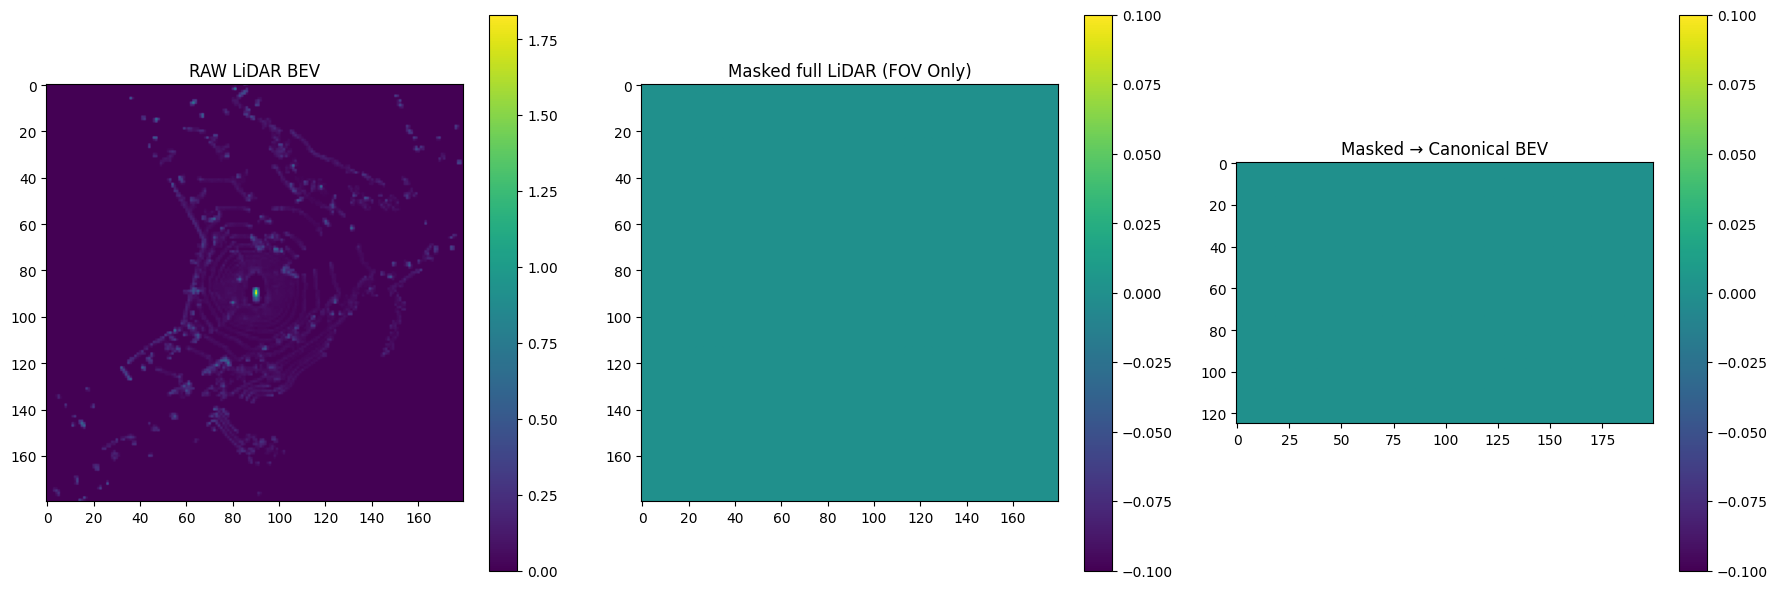

In [14]:
import sys
sys.path.append("/home/draiman/Desktop/Nima/Lavis_blip2")
import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
from  lavis.models.crop_lidar_bev import crop_lidar_bev_to_camera_fov

token = "e93e98b63d3b40209056d129dc53ceee"

lidar_file_full = f"/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/features_CP_layers/benign_early_layers.pt"

cam_resnet_file = f"/home/draiman/Desktop/Datasets_nuscenes/train/resnet/CAM_FRONT/{token}.pt"
cam_fpn_file = f"/home/draiman/Desktop/Datasets_nuscenes/train/fpn/CAM_FRONT/{token}_lvl0.pt"


# Load LiDAR BEV
# lidar_raw_full = torch.load(lidar_file)["bev_c2"].squeeze(0)   # [C, H, W]


# Load camera ResNet (contains calibration!)
cam_raw = torch.load(cam_resnet_file, map_location="cpu")
# lidar2img = cam_raw["lidar2img"]
# img_shape = tuple(cam_raw["img_shape"][0])[:2]  # (H, W)

lidar2img = lidar2img_nusc
img_shape = img_shape_nusc


lidar_raw_full_o = torch.load(lidar_file_full)
lidar_raw_full_nusc = lidar_raw_full_o['spatial'].squeeze(0)
    
masked_full_lidar_nusc = crop_lidar_bev_to_camera_fov(
    lidar_raw_full_nusc,
    lidar2img,
    img_shape,
    # bev_resolution=(1.14, 1.14),
    bev_resolution = (0.57, 0.57),
    pc_range=[-51.2, -51.2, -5.0, 51.2, 51.2, 3.0]
)


class BEVSpec:
    def __init__(self, x_min, x_max, cell_x, y_min, y_max, cell_y):
        self.x_min = x_min
        self.x_max = x_max
        self.cell_x = cell_x
        self.y_min = y_min
        self.y_max = y_max
        self.cell_y = cell_y

    @property
    def H(self):
        return int(np.ceil((self.x_max - self.x_min) / self.cell_x))

    @property
    def W(self):
        return int(np.ceil((self.y_max - self.y_min) / self.cell_y))

bev_spec = BEVSpec(0, 50, 0.4, -25, 25, 0.25)


# Lidar masked: [C, H_raw, W_raw] → add batch
lidar_masked_full_batch = masked_full_lidar_nusc.unsqueeze(0)

x_min_l, y_min_l, _, x_max_l, y_max_l, _ = [-51.2, -51.2, -5, 51.2, 51.2, 3]

xs = bev_spec.x_min + (torch.arange(bev_spec.H) + 0.5) * bev_spec.cell_x
ys = bev_spec.y_min + (torch.arange(bev_spec.W) + 0.5) * bev_spec.cell_y
Xg, Yg = torch.meshgrid(xs, ys, indexing='ij')

grid_x = 2 * (Yg - y_min_l) / (y_max_l - y_min_l) - 1
grid_y = 2 * (Xg - x_min_l) / (x_max_l - x_min_l) - 1
grid = torch.stack([grid_x, grid_y], dim=-1).unsqueeze(0)

lidar_bev_canonical_nusc = F.grid_sample(
    lidar_masked_full_batch, grid,
    mode='bilinear', padding_mode='zeros', align_corners=True
).squeeze(0)




masked_full_lidar_mean = masked_full_lidar_nusc.mean(0).numpy()


plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.title("RAW LiDAR BEV")
plt.imshow(lidar_raw_full_nusc.mean(0), cmap='viridis')
plt.colorbar()



plt.subplot(1, 3, 2)
plt.title("Masked full LiDAR (FOV Only)")
plt.imshow(masked_full_lidar_nusc.mean(0), cmap='viridis')
plt.colorbar()


plt.subplot(1, 3, 3)
plt.title("Masked → Canonical BEV")
plt.imshow(lidar_bev_canonical_nusc.mean(0), cmap='viridis')
plt.colorbar()

plt.tight_layout()
plt.show()



In [1]:
# Save to CSV
import csv
import numpy as np
from nuscenes.nuscenes import NuScenes
from pyquaternion import Quaternion

def get_lidar2img_from_nuscenes(nusc, sample_token, cam_channel="CAM_FRONT"):
    sample = nusc.get("sample", sample_token)
    sd_lidar = nusc.get("sample_data", sample["data"]["LIDAR_TOP"])
    sd_cam = nusc.get("sample_data", sample["data"][cam_channel])
    cs_lidar = nusc.get("calibrated_sensor", sd_lidar["calibrated_sensor_token"])
    cs_cam = nusc.get("calibrated_sensor", sd_cam["calibrated_sensor_token"])
    ep_lidar = nusc.get("ego_pose", sd_lidar["ego_pose_token"])
    ep_cam = nusc.get("ego_pose", sd_cam["ego_pose_token"])
    lidar2ego = np.eye(4)
    lidar2ego[:3, :3] = Quaternion(cs_lidar["rotation"]).rotation_matrix
    lidar2ego[:3, 3] = cs_lidar["translation"]
    ego_lidar2global = np.eye(4)
    ego_lidar2global[:3, :3] = Quaternion(ep_lidar["rotation"]).rotation_matrix
    ego_lidar2global[:3, 3] = ep_lidar["translation"]
    global2ego_cam = np.eye(4)
    global2ego_cam[:3, :3] = Quaternion(ep_cam["rotation"]).rotation_matrix.T
    global2ego_cam[:3, 3] = -global2ego_cam[:3, :3].dot(ep_cam["translation"])
    ego_cam2cam = np.eye(4)
    ego_cam2cam[:3, :3] = Quaternion(cs_cam["rotation"]).rotation_matrix.T
    ego_cam2cam[:3, 3] = -ego_cam2cam[:3, :3].dot(cs_cam["translation"])
    lidar2cam = ego_cam2cam @ global2ego_cam @ ego_lidar2global @ lidar2ego
    K = np.array(cs_cam["camera_intrinsic"])
    lidar2img = K @ lidar2cam[:3, :]
    R = Quaternion(cs_cam["rotation"]).rotation_matrix
    T = np.array(cs_cam["translation"])
    img_shape = (sd_cam["height"], sd_cam["width"])
    return R, T, K, lidar2img, img_shape

def save_calib_to_csv_minimal(nusc, sample_tokens, cam_channel="CAM_FRONT", out_csv="calib_minimal.csv"):
    with open(out_csv, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([
            "sample_token", "cam_channel",
            "K_flat", "R_flat", "T_flat",
            "lidar2img_flat", "img_height", "img_width"
        ])
        for token in sample_tokens:
            R, T, K, lidar2img, img_shape = get_lidar2img_from_nuscenes(nusc, token, cam_channel)
            writer.writerow([
                token, cam_channel,
                K.flatten().tolist(),
                R.flatten().tolist(),
                T.flatten().tolist(),
                lidar2img.flatten().tolist(),
                img_shape[0], img_shape[1]
            ])
    print(f"[INFO] Minimal calibration info saved to {out_csv}")

# Example usage:
nusc = NuScenes(
    version='v1.0-trainval',
    dataroot="/home/draiman/Desktop/datasets/nuscenes",
    verbose=False
)
sample_tokens = [s['token'] for s in nusc.sample[:50]]  # Example: first 50
save_calib_to_csv_minimal(nusc, sample_tokens, "CAM_FRONT", "calib_minimal.csv")


[INFO] Minimal calibration info saved to calib_minimal.csv


In [ ]:
# Load from CSV (Minimal)
import csv
import numpy as np

def load_calib_from_csv_minimal(csv_file, query_token, cam_channel="CAM_FRONT"):
    with open(csv_file, mode='r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            if row["sample_token"] == query_token and row["cam_channel"] == cam_channel:
                K = np.array(eval(row["K_flat"])).reshape(3, 3)
                R = np.array(eval(row["R_flat"])).reshape(3, 3)
                T = np.array(eval(row["T_flat"])).reshape(3,)
                lidar2img = np.array(eval(row["lidar2img_flat"])).reshape(3, 4)
                img_shape = (int(row["img_height"]), int(row["img_width"]))
                return {
                    "K": K, "R": R, "T": T, "lidar2img": lidar2img, "img_shape": img_shape
                }
    raise KeyError(f"Sample {query_token} with channel {cam_channel} not found in CSV.")

# Example:
query_token = "e93e98b63d3b40209056d129dc53ceee"
calib_info = load_calib_from_csv_minimal("calib_minimal.csv", query_token, "CAM_FRONT")
print(calib_info["K"], calib_info["R"], calib_info["T"], calib_info["lidar2img"], calib_info["img_shape"])
img_shape_nusc = calib_info["img_shape"]
lidar2img_nusc = calib_info["lidar2img"]
# print("lidar2img_nusc", lidar2img_nusc)
# print('img_shape_nusc', img_shape_nusc)


KeyError: 'Sample f9878012c3f6412184c294c13ba4bac3 with channel CAM_FRONT not found in CSV.'

xs torch.Size([125])
ys torch.Size([200])
grid_x torch.Size([125, 200])
grid_y torch.Size([125, 200])


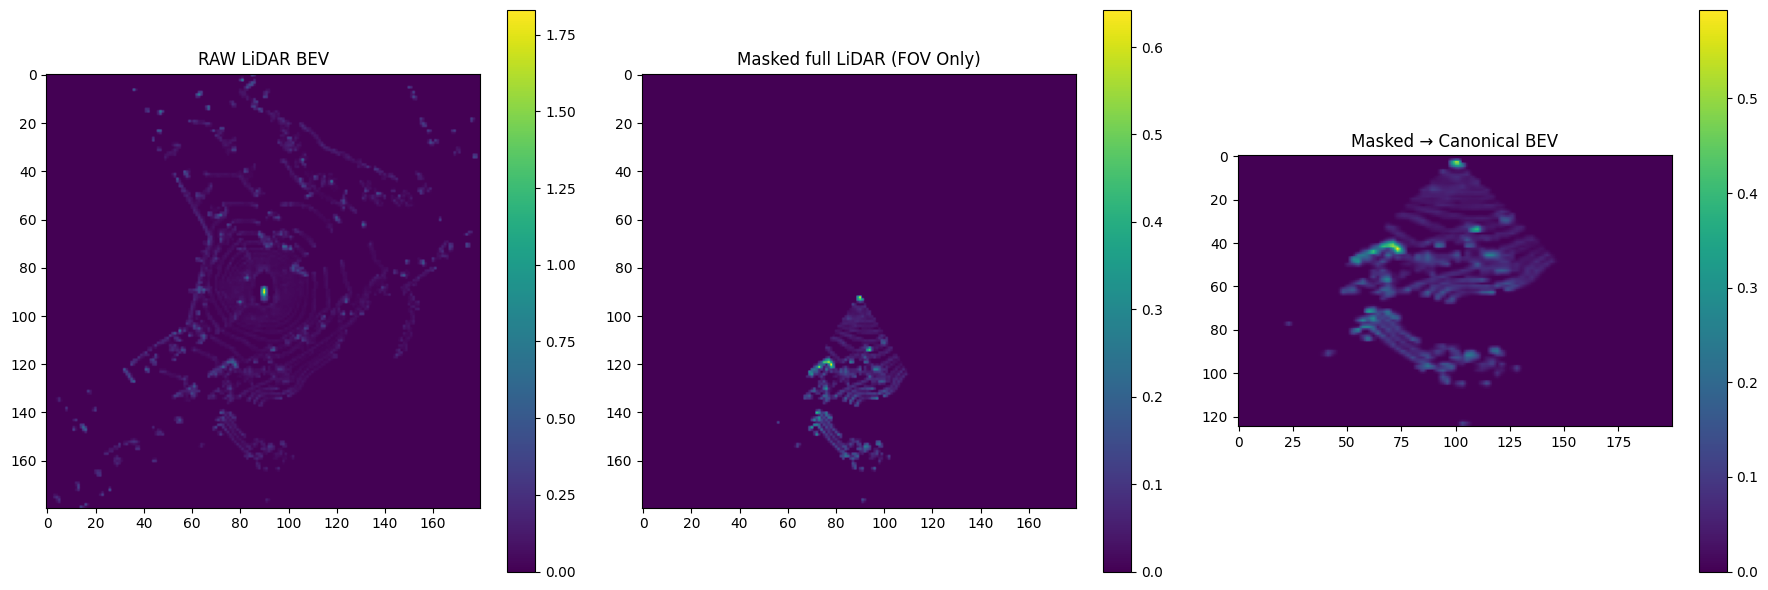

In [ ]:
import sys
sys.path.append("/home/draiman/Desktop/Nima/Lavis_blip2")
import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
from  lavis.models.crop_lidar_bev import crop_lidar_bev_to_camera_fov

token = "e93e98b63d3b40209056d129dc53ceee"

lidar_file_full = f"/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/features_CP_layers/benign_early_layers.pt"

cam_resnet_file = f"/home/draiman/Desktop/Datasets_nuscenes/train/resnet/CAM_FRONT/{token}.pt"
cam_fpn_file = f"/home/draiman/Desktop/Datasets_nuscenes/train/fpn/CAM_FRONT/{token}_lvl0.pt"


# Load LiDAR BEV
# lidar_raw_full = torch.load(lidar_file)["bev_c2"].squeeze(0)   # [C, H, W]


# Load camera ResNet (contains calibration!)
cam_raw = torch.load(cam_resnet_file, map_location="cpu")
# lidar2img = cam_raw["lidar2img"]
# img_shape = tuple(cam_raw["img_shape"][0])[:2]  # (H, W)

lidar2img = lidar2img_nusc
img_shape = img_shape_nusc


lidar_raw_full_o = torch.load(lidar_file_full)
lidar_raw_full_nusc = lidar_raw_full_o['spatial'].squeeze(0)
    
masked_full_lidar_nusc = crop_lidar_bev_to_camera_fov(
    lidar_raw_full_nusc,
    lidar2img,
    img_shape,
    # bev_resolution=(1.14, 1.14),
    bev_resolution = (0.57, 0.57),
    pc_range=[-51.2, -51.2, -5.0, 51.2, 51.2, 3.0]
)


class BEVSpec:
    def __init__(self, x_min, x_max, cell_x, y_min, y_max, cell_y):
        self.x_min = x_min
        self.x_max = x_max
        self.cell_x = cell_x
        self.y_min = y_min
        self.y_max = y_max
        self.cell_y = cell_y

    @property
    def H(self):
        return int(np.ceil((self.x_max - self.x_min) / self.cell_x))

    @property
    def W(self):
        return int(np.ceil((self.y_max - self.y_min) / self.cell_y))

bev_spec = BEVSpec(0, 50, 0.4, -25, 25, 0.25)


# Lidar masked: [C, H_raw, W_raw] → add batch
lidar_masked_full_batch = masked_full_lidar_nusc.unsqueeze(0)

x_min_l, y_min_l, _, x_max_l, y_max_l, _ = [-51.2, -51.2, -5, 51.2, 51.2, 3]

xs = bev_spec.x_min + (torch.arange(bev_spec.H) + 0.5) * bev_spec.cell_x
ys = bev_spec.y_min + (torch.arange(bev_spec.W) + 0.5) * bev_spec.cell_y
Xg, Yg = torch.meshgrid(xs, ys, indexing='ij')

grid_x = 2 * (Yg - y_min_l) / (y_max_l - y_min_l) - 1
grid_y = 2 * (Xg - x_min_l) / (x_max_l - x_min_l) - 1
grid = torch.stack([grid_x, grid_y], dim=-1).unsqueeze(0)

lidar_bev_canonical_nusc = F.grid_sample(
    lidar_masked_full_batch, grid,
    mode='bilinear', padding_mode='zeros', align_corners=True
).squeeze(0)


print("xs", xs.shape)
print("ys", ys.shape)
print("grid_x", grid_x.shape)
print("grid_y", grid_y.shape)

masked_full_lidar_mean = masked_full_lidar_nusc.mean(0).numpy()


plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.title("RAW LiDAR BEV")
plt.imshow(lidar_raw_full_nusc.mean(0), cmap='viridis')
plt.colorbar()



plt.subplot(1, 3, 2)
plt.title("Masked full LiDAR (FOV Only)")
plt.imshow(masked_full_lidar_nusc.mean(0), cmap='viridis')
plt.colorbar()


plt.subplot(1, 3, 3)
plt.title("Masked → Canonical BEV")
plt.imshow(lidar_bev_canonical_nusc.mean(0), cmap='viridis')
plt.colorbar()

plt.tight_layout()
plt.show()



torch.Size([1, 256, 116, 200])
H_bev 125
W_bev 200
BEV shape: torch.Size([256, 125, 200])


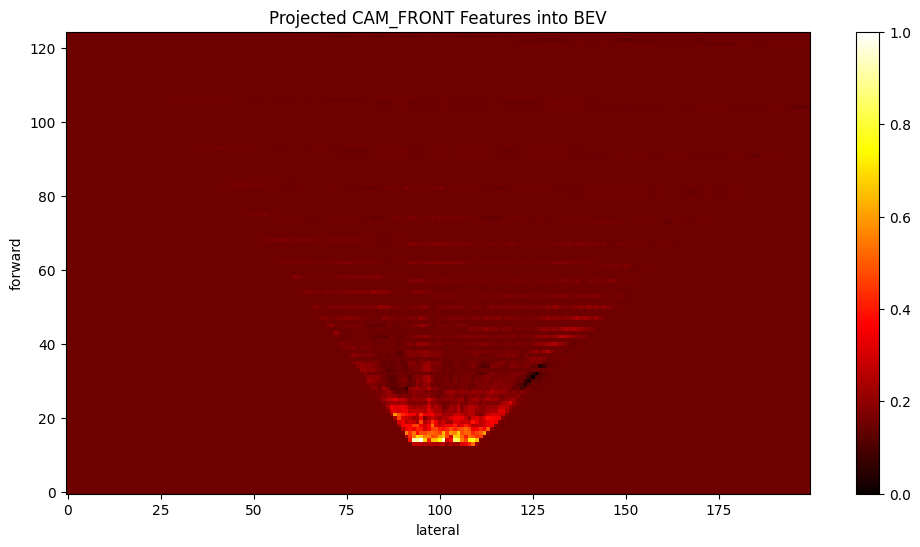

In [12]:
import torch, os
import numpy as np

# -- Settings
calib_csv = "calib_minimal.csv"
camera_dir = "/home/draiman/Desktop/Datasets_nuscenes/train/fpn/CAM_FRONT"
sample_token = "e93e98b63d3b40209056d129dc53ceee"  # Or any sample token
cam_channel = "CAM_FRONT"
fpn_level = 0

# -- Load calibration from CSV
calib = load_calib_from_csv_minimal(calib_csv, sample_token, cam_channel)
K = calib["K"]
R_cam2ego = calib["R"]
T_cam2ego = calib["T"]
img_shape = calib["img_shape"]

# -- Load your FPN P2 features
pt_path = os.path.join(camera_dir, f"{sample_token}_lvl{fpn_level}.pt")
cam = torch.load(pt_path, map_location='cpu')
cam_feat = cam['feat']   # [1, C, Hf, Wf]
if cam_feat.ndim == 3:
    cam_feat = cam_feat.unsqueeze(0)
B, C, Hf, Wf = cam_feat.shape
print(cam_feat.shape)

# -- Compute pixel centers for feature map (using correct stride)
stride = img_shape[0] // Hf   # Assumes integer stride; adjust as needed
i = torch.arange(Hf, dtype=torch.float32) + 0.5
j = torch.arange(Wf, dtype=torch.float32) + 0.5
V, U = torch.meshgrid(i * stride, j * stride, indexing='ij')
U = U.numpy()
V = V.numpy()

# -- Backproject rays → camera → ego
K_inv = np.linalg.inv(K)
uv1 = np.stack([U.reshape(-1), V.reshape(-1), np.ones(Hf*Wf)], axis=0)
rays_cam = K_inv @ uv1
rays_cam[1, :] *= -1  # flip y
rays_ego = R_cam2ego @ rays_cam
C_ego = T_cam2ego.reshape(3)

# -- Intersect rays with ground plane z = 0
cam_z = C_ego[2]
dir_z = rays_ego[2, :]
s = -cam_z / (dir_z + 1e-12)
valid = s > 0
X = C_ego[0] + s * rays_ego[0, :]
Y = C_ego[1] + s * rays_ego[1, :]

# -- Define BEV grid
cell_x = 0.4
cell_y = 0.25
x_min, x_max = 0, 50
y_min, y_max = -25, 25
H_bev = int(np.ceil((x_max - x_min) / cell_x))
W_bev = int(np.ceil((y_max - y_min) / cell_y))
bev = torch.zeros((C, H_bev, W_bev))

# -- Splat features into BEV
ix = ((X - x_min) / cell_x).astype(np.int64)
iy = ((Y - y_min) / cell_y).astype(np.int64)
inside = valid & (ix>=0)&(ix<H_bev)&(iy>=0)&(iy<W_bev)
feat_flat = cam_feat.reshape(C, -1)
for n in np.where(inside)[0]:
    bev[:, ix[n], iy[n]] += feat_flat[:, n]


print("H_bev", H_bev)
print("W_bev", W_bev)
print("BEV shape:", bev.shape)

# -- Visualize BEV heatmap
import matplotlib.pyplot as plt
heat = bev.mean(dim=0).numpy()
heat = (heat - heat.min()) / (heat.max() - heat.min() + 1e-8)
plt.figure(figsize=(12,6))
plt.imshow(heat, cmap='hot', origin='lower', aspect='auto')
plt.colorbar()
plt.xlabel("lateral")
plt.ylabel("forward")
plt.title("Projected CAM_FRONT Features into BEV")
plt.show()


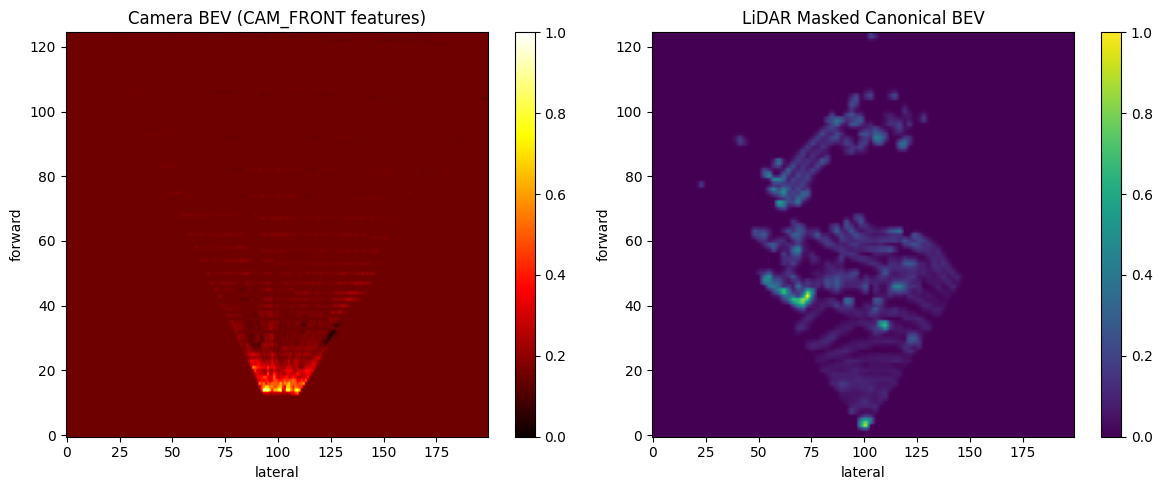

In [11]:
import matplotlib.pyplot as plt

# --- Compute normalized camera BEV heatmap ---
heat_cam = bev.mean(dim=0).numpy()
heat_cam = (heat_cam - heat_cam.min()) / (heat_cam.max() - heat_cam.min() + 1e-8)

# --- Compute normalized LiDAR BEV heatmap ---
heat_lidar = lidar_bev_canonical_nusc.mean(0).numpy()
heat_lidar = (heat_lidar - heat_lidar.min()) / (heat_lidar.max() - heat_lidar.min() + 1e-8)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Camera BEV (CAM_FRONT features)")
plt.imshow(heat_cam, cmap='hot', origin='lower', aspect='auto')
plt.colorbar()
plt.xlabel("lateral")
plt.ylabel("forward")

plt.subplot(1, 2, 2)
plt.title("LiDAR Masked Canonical BEV")
plt.imshow(heat_lidar, cmap='viridis', origin='lower', aspect='auto')
plt.colorbar()
plt.xlabel("lateral")
plt.ylabel("forward")

plt.tight_layout()
plt.show()
